In [1]:
%load_ext autoreload
%autoreload 2

In [38]:
import os
from box import Box
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from typing import Callable, Union, Dict, Any

from scripts.logger import Logger
from scripts.mri.mri_iteration import MriIteration
from utils.makepath import makepath as mkp
from config.config_loader import load_config
from data.mri.data_loader import get_data_loader, get_dataset
from scripts.epoch import perform_epoch
from scripts.mri.test.test_utils import get_config_and_model
from encoding_objects.cart_2d_enc_obj import Cart2DEncObj
from utils.metrics import ImageMetricsEvaluator

In [3]:
# device = "cpu"
device = "cuda:0"
# device = "cuda:1"
# device = "mps"

In [4]:
root_dir = mkp("..", "..")

In [5]:
# data_config, u_tv_net, u_tgv_net = get_data_config_and_models(
#     device=device,
#     root_dir=root_dir,
# )

In [6]:
u_tv_config, u_tv_net = get_config_and_model(
    # model_id="u_tv_fixed", state_dict_file="model_state_dict_43.pth",
    model_id="low_field_u_tv", state_dict_file="model_state_dict_50.pth",
    device=device,
    root_dir=root_dir,
)
print(f"U-TV sigma: {u_tv_net.sigma}")
print(f"U-TV tau: {u_tv_net.tau}")

Config loaded from file ../../pretrained/low_field_u_tv/config.yaml
Config loaded from dict
Loading model on device: cuda:0
Norm of operator A: 1
Norm of gradient operator nabla: 2.8284270763397217
L: 3.0
PDHG net device: cuda:0
Using my U-Net implementation!
Loading model on device: cuda:0
Using my own UNet2d class
Loaded model state dict from ../../pretrained/low_field_u_tv/model_state_dict_50.pth
low_field_u_tv model loaded
U-TV sigma: 11.98429012298584
U-TV tau: 0.00927139725536108


In [7]:
u_tgv_config, u_tgv_net = get_config_and_model(
    # model_id="u_tgv_fixed", state_dict_file="model_state_dict_72.pth",
    model_id="low_field_u_tgv", state_dict_file="model_state_dict_43_epoch_26.pth",
    device=device,
    root_dir=root_dir,
)
print(f"U-TGV sigma: {u_tgv_net.sigma}")
print(f"U-TGV tau: {u_tgv_net.tau}")

Config loaded from file ../../pretrained/low_field_u_tgv/config.yaml
Config loaded from dict
Loading model on device: cuda:0
Norm of operator A: 1
Norm of gradient operator nabla: 2.8284270763397217
L: 3.0
PDHG net device: cuda:0
Using my U-Net implementation!
Loading model on device: cuda:0
Using my own UNet2d class
Loaded model state dict from ../../pretrained/low_field_u_tgv/model_state_dict_43_epoch_26.pth
low_field_u_tgv model loaded
U-TGV sigma: 1.5162570476531982
U-TGV tau: 0.07327987253665924


In [8]:
u_tv_config["data"]

Box({'batch_size': 1, 'data_path': PosixPath('../../tmp/mri_data'), 'data_scale_factor': 1000, 'dataset': 'mri', 'img_size': 320, 'loading_method': 'dynamically_noised', 'max_standard_deviation_sigma': 0.3, 'min_standard_deviation_sigma': 0.0, 'random_seed': 42, 'super_resolution_factor': 2.0, 'test_file_name': 'x_true_test_302.pt', 'test_num_samples': 302, 'train_file_name': 'x_true_train_3000.pt', 'train_num_samples': 3000, 'undersampling': 'low_field', 'val_file_name': 'x_true_val_150.pt', 'val_num_samples': 150})

In [9]:
u_tgv_config["data"]

Box({'batch_size': 1, 'data_path': PosixPath('../../tmp/mri_data'), 'data_scale_factor': 1000, 'dataset': 'mri', 'img_size': 320, 'loading_method': 'dynamically_noised', 'max_standard_deviation_sigma': 0.3, 'min_standard_deviation_sigma': 0.0, 'random_seed': 42, 'super_resolution_factor': 2.0, 'test_file_name': 'x_true_test_302.pt', 'test_num_samples': 302, 'train_file_name': 'x_true_train_3000.pt', 'train_num_samples': 3000, 'undersampling': 'low_field', 'val_file_name': 'x_true_val_150.pt', 'val_num_samples': 150})

In [10]:
assert u_tv_config["data"] == u_tgv_config["data"]
data_config = u_tv_config["data"]
data_config = u_tgv_config["data"]

In [11]:
# acceleration_factor_R = 8
super_res = 2
# gaussian_noise_standard_deviation_sigma = 0.05
gaussian_noise_standard_deviation_sigma = 0.3

In [12]:
test_dataset = get_dataset(
    data_config=data_config,
    dataset_type="preprocessed",
    action="test",
    device=device,
    # acceleration_factor_R=acceleration_factor_R,
    args=f"super_res_{super_res}",
    args_box=Box({"super_res": super_res}),
    gaussian_noise_standard_deviation_sigma=gaussian_noise_standard_deviation_sigma
)

Shape of loaded x_corrupted: torch.Size([302, 320, 320])
Shape of loaded kdata_corrupted: torch.Size([302, 1, 320, 320])
Shape of loaded undersampling_kmasks: torch.Size([302, 320, 320])


Ground truth data shape: torch.Size([302, 320, 320])
min abs val of ground truth: 1.8633207901075366e-06
max abs val of ground truth: 1.385725498199463
Shape of corrupted data: torch.Size([302, 320, 320])
Shape of corrupted kdata: torch.Size([302, 1, 320, 320])
Shape of kmasks: torch.Size([302, 320, 320])

Ground truth data shape: torch.Size([302, 320, 320])
Memory size of ground truth: 235.9375 MB
Corrupted data shape: torch.Size([302, 320, 320])
Memory size of corrupted data: 235.9375 MB
min abs val of corrupted: 2.774341055555851e-06
max abs val of corrupted: 1.326708197593689

Corrupted kdata shape: torch.Size([302, 1, 320, 320])
Memory size of corrupted kdata: 235.9375 MB

kmasks shape: torch.Size([302, 320, 320])
Memory size of kmasks: 235.9375 MB



In [13]:
enc_obj = Cart2DEncObj()

In [14]:
metrics_evaluator = ImageMetricsEvaluator(
    complex_to_real_conversion="abs", device=device)

NOTE: Complex-to-real conversion method: abs


In [15]:
out_dir = mkp(".", str(device))
os.makedirs(out_dir, exist_ok=True)
print(f"Output directory: {out_dir}")

Output directory: cuda:0


In [16]:
plt.figure(figsize=(24, 20))
from scripts.mri.test.test_utils import TestImageSaver
test_image_saver = TestImageSaver(
    # acc_factor_R=acceleration_factor_R,
    args=f"super_res_{super_res}",
    args_box=Box({"super_res": super_res}),
    gaussian_noise_sigma=gaussian_noise_standard_deviation_sigma,
    complex_to_real_conversion="abs",
    root_dir=root_dir,

    # saves=False,
    # sample_idx=0,
    # dataset=test_dataset,
    data_config=data_config,
    # enc_obj=enc_obj,
    u_tv_net=u_tv_net,
    u_tgv_net=u_tgv_net,
    num_iters=256,

    out_dir=out_dir,
    # metrics_evaluator=metrics_evaluator,
    x_clip_range=(0, 0.5),
    kdata_clip_range=(0, 0.2),
    lambda1_v_clip_range=(0, 0.05),
    lambda0_w_clip_range=(0, 1),
    lambda_ratio_clip_range=(0, 10),
    tqdm_progress_bar=tqdm,

    fraction_of_line_width=1,
    height_to_width_ratio=1,
    device=device,
)


Shape of loaded x_corrupted: torch.Size([302, 320, 320])
Shape of loaded kdata_corrupted: torch.Size([302, 1, 320, 320])
Shape of loaded undersampling_kmasks: torch.Size([302, 320, 320])


Ground truth data shape: torch.Size([302, 320, 320])
min abs val of ground truth: 1.8633207901075366e-06
max abs val of ground truth: 1.385725498199463
Shape of corrupted data: torch.Size([302, 320, 320])
Shape of corrupted kdata: torch.Size([302, 1, 320, 320])
Shape of kmasks: torch.Size([302, 320, 320])

Ground truth data shape: torch.Size([302, 320, 320])
Memory size of ground truth: 235.9375 MB
Corrupted data shape: torch.Size([302, 320, 320])
Memory size of corrupted data: 235.9375 MB
min abs val of corrupted: 2.774341055555851e-06
max abs val of corrupted: 1.326708197593689

Corrupted kdata shape: torch.Size([302, 1, 320, 320])
Memory size of corrupted kdata: 235.9375 MB

kmasks shape: torch.Size([302, 320, 320])
Memory size of kmasks: 235.9375 MB

NOTE: Complex-to-real conversion method: abs


<Figure size 2400x2000 with 0 Axes>

batch_x_corrupted.shape = torch.Size([1, 320, 320])
batch_x_true.shape = torch.Size([1, 320, 320])
batch_kdata_corrupted.shape = torch.Size([1, 1, 320, 320])
batch_undersampling_kmask.shape = torch.Size([1, 320, 320])
Reconstructing with U-TGV ...


  0%|          | 0/256 [00:00<?, ?it/s]

Reconstructing with U-TV ...


  0%|          | 0/256 [00:00<?, ?it/s]

Saving kdata image
Saving ground_truth image
Saving mask image
Saving kdata_corrupted image
Saving zero_filled image
abs - zero_filled metrics: PSNR = 28.84, SSIM = 0.6344
Saving lambda image
Saving u_tv image
abs - u_tv metrics: PSNR = 32.42, SSIM = 0.7564
Saving lambda0_w image
Saving lambda1_v image
Saving u_tgv image
abs - u_tgv metrics: PSNR = 32.91, SSIM = 0.8258
Saving lambda0_w_over_lambda1_v image


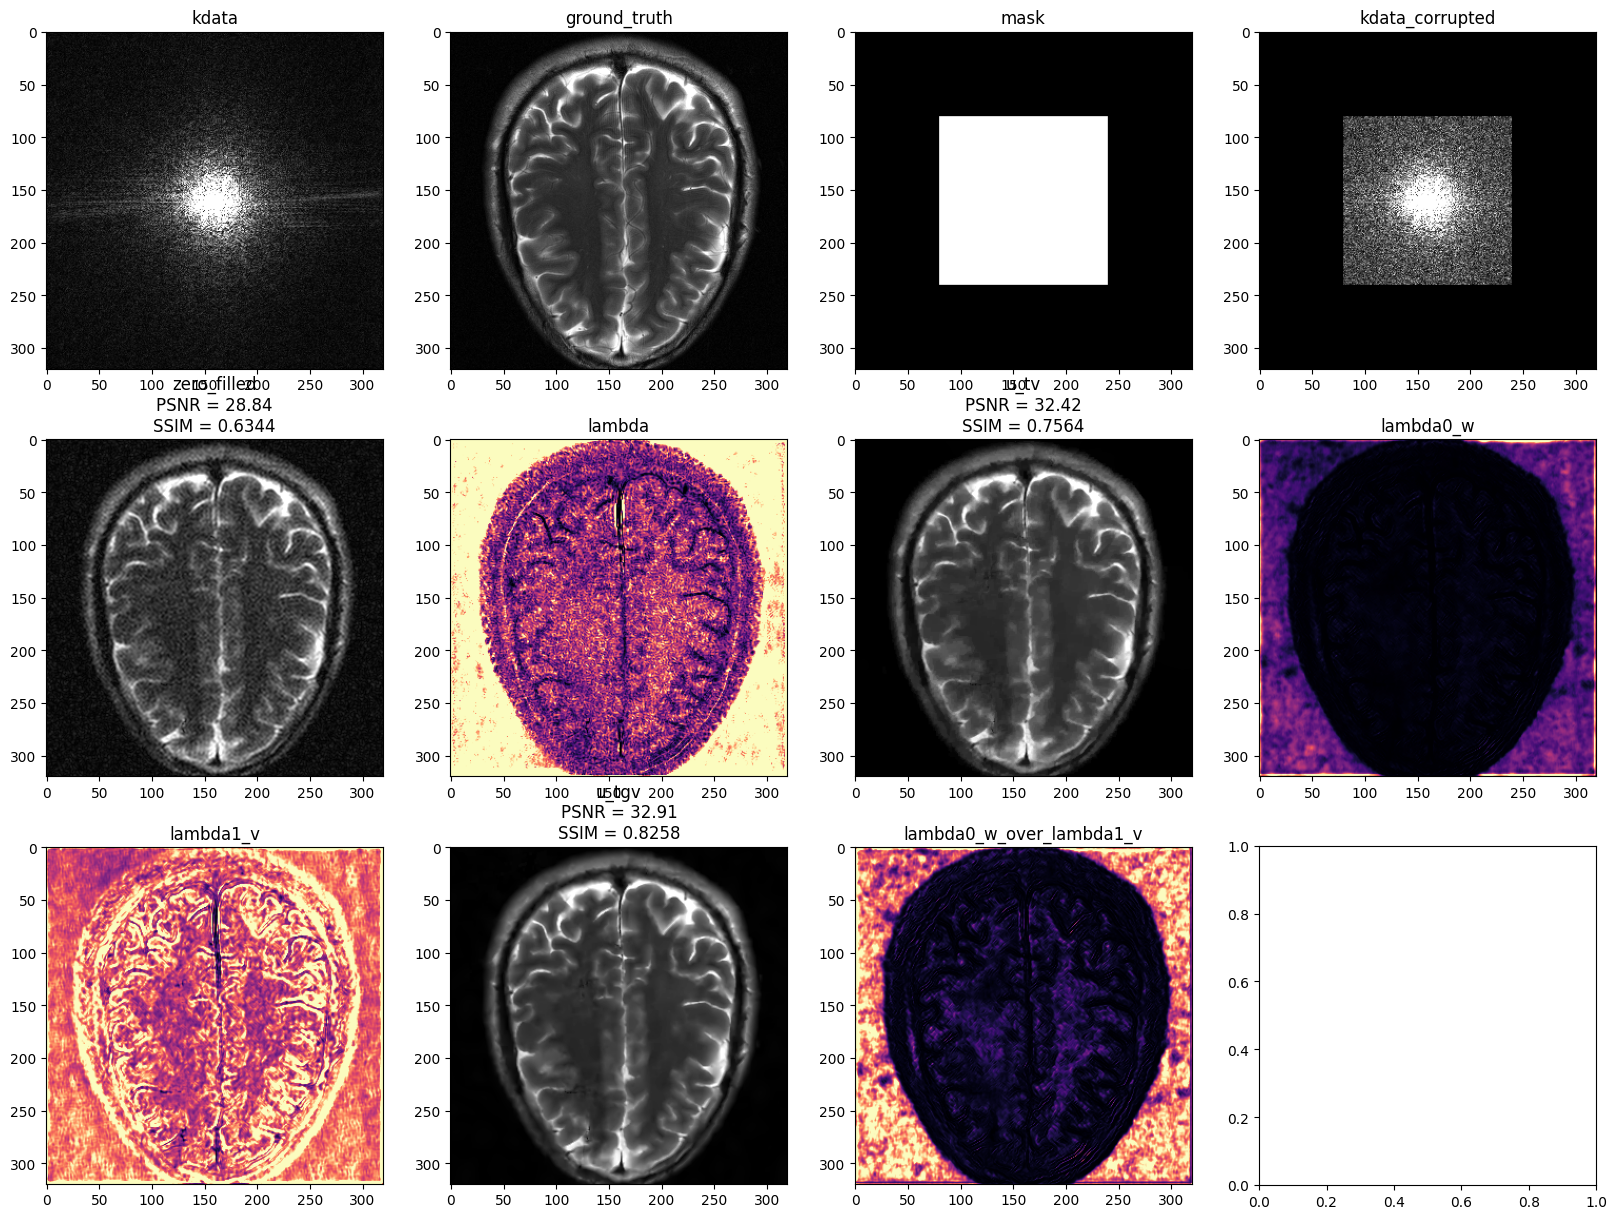

In [17]:
test_image_saver.test_sample_and_save_images(
    sample_idx=0,
)

In [48]:
def get_zero_filled(
    batch_kdata,
    batch_kmask,
    batch_x,
    batch_csmap
):
    return batch_x, None

In [ ]:
def test_and_save_results(
        config: Dict[str, Any],
        reconstructor: Union[torch.nn.Module, Callable],
        general_action: str,
        # acceleration_factor_R: int,
        args: str,
        args_box: Box,
        sigma: float,
        force_overwrite: bool = False
):
    print(f"Testing with {general_action} data, {args}, sigma = {sigma}")

    test_data_loader = get_data_loader(
        data_config=config['data'],
        action=general_action,
        dataset_type="preprocessed",
        device=device,
        args=args,
        args_box=args_box,
        gaussian_noise_standard_deviation_sigma=sigma
    )

    specific_action = f"{general_action}-{args}-sigma_{sigma:.2f}".replace(".", "_")

    test_logger = Logger(
        action=specific_action,
        config=config,
        force_overwrite=force_overwrite
    )
    test_logger.init_metrics_logging_options()
    # Set the intermediate log frequency to 1
    test_logger.log_freq_by_iter["intermediate"] = 1
    mri_iteration = MriIteration(
        model=reconstructor,
        metrics_evaluator=metrics_evaluator,
    )
    avg_metrics = perform_epoch(
        data_loader=test_data_loader,
        # pdhg_net=reconstructor,
        perform_iteration=mri_iteration.perform_iteration,
        is_training=False,
        logger=test_logger,
        # learning_rate_scheduler=None,
        # optimizer=None,
        tqdm=tqdm
    )
    return avg_metrics

In [50]:
zero_filled_config = load_config(
    config_choice=mkp(root_dir, "config", "zero_filled_config.yaml"),
    is_training=False,
    root_dir=root_dir
)

Config loaded from file ../../config/zero_filled_config.yaml


In [54]:
# acceleration_factor_R = 4
# sigma = 0.15
# general_action = "test"
# # action = "val"
# force_overwrite = False
# # force_overwrite = True

# for acceleration_factor_R in []:
for args, args_box in [("super_res_2", Box({"super_res": 2}))]:
    for sigma in [0.3]:
        test_and_save_results(
            config=zero_filled_config,
            reconstructor=get_zero_filled,
            # reconstructor=u_tv_net,
            # reconstructor=u_tgv_net,
            general_action="test",
            sigma=sigma,
            args=args,
            args_box=args_box,
            # force_overwrite=False
            force_overwrite=True
        )

Testing with test data, super_res_2, sigma = 0.3
Shape of loaded x_corrupted: torch.Size([302, 320, 320])
Shape of loaded kdata_corrupted: torch.Size([302, 1, 320, 320])
Shape of loaded undersampling_kmasks: torch.Size([302, 320, 320])


Ground truth data shape: torch.Size([302, 320, 320])
min abs val of ground truth: 1.8633207901075366e-06
max abs val of ground truth: 1.385725498199463
Shape of corrupted data: torch.Size([302, 320, 320])
Shape of corrupted kdata: torch.Size([302, 1, 320, 320])
Shape of kmasks: torch.Size([302, 320, 320])

Ground truth data shape: torch.Size([302, 320, 320])
Memory size of ground truth: 235.9375 MB
Corrupted data shape: torch.Size([302, 320, 320])
Memory size of corrupted data: 235.9375 MB
min abs val of corrupted: 2.774341055555851e-06
max abs val of corrupted: 1.326708197593689

Corrupted kdata shape: torch.Size([302, 1, 320, 320])
Memory size of corrupted kdata: 235.9375 MB

kmasks shape: torch.Size([302, 320, 320])
Memory size of kmasks: 235.9375 M

  0%|          | 0/302 [00:00<?, ?it/s]

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 